

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>2.1 Data Load
</b></div>

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
from joblib import load, dump
import warnings

In [127]:
df = pd.read_csv('../Dataset/credit_risk_data_cleaned.csv')



# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>2.2 Feature Engineering and split
</b></div>

In [128]:
def feature_engineering(df):
    df['income_to_loan'] = df['person_income'] / (df['loan_amnt'] + 1)
    df['age_to_emp_length'] = df['person_age'] / (df['person_emp_length'] + 1)
    df['log_income'] = np.log1p(df['person_income'])
    df['age_to_credit_history'] = df['person_age'] / (df['cb_person_cred_hist_length'] )
    df['stability_score'] = (df['person_emp_length'] * df['person_income']) / (df['loan_amnt'] * (df['cb_person_cred_hist_length'] + 1))
    df['rate_to_age'] = df['loan_int_rate'] / df['person_age']
    return df
df = feature_engineering(df)

In [129]:

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['id']).tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)
print()

X = df.drop(columns=['id','loan_status'])
y = df['loan_status']
print("Features shape:", X.shape)
print("Target shape:", y.shape)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Features after encoding shape:", X.shape)

Categorical Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Numerical Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status', 'income_to_loan', 'age_to_emp_length', 'log_income', 'age_to_credit_history', 'stability_score', 'rate_to_age']

Features shape: (91051, 17)
Target shape: (91051,)
Features after encoding shape: (91051, 28)


In [130]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (72840, 28) (72840,)
Test set shape: (18211, 28) (18211,)


In [131]:
joblib.dump([X_train, X_test, y_train, y_test], '../train_test_split.pkl')

print("Successfully dumped all 4 sets to a single file.")

Successfully dumped all 4 sets to a single file.




# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>2.3 Models
</b></div>

## Random Forest

In [132]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [133]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='roc_auc')
print("Random Forest CV AUC Scores:", rf_scores)
print(f"Mean AUC : {np.mean(rf_scores):.4f}")
print(f"Std AUC : {np.std(rf_scores):.4f}")

Random Forest CV AUC Scores: [0.93931223 0.93699459 0.93925861 0.93357671 0.9421619 ]
Mean AUC : 0.9383
Std AUC : 0.0029


## XGB

In [134]:
xgb_model = XGBClassifier(random_state=42)
xgb_scores = cross_val_score(xgb_model, X_train, y_train, cv=kf, scoring='roc_auc')
print("XGBoost CV AUC Scores:", xgb_scores)
print(f"Mean AUC : {np.mean(xgb_scores):.4f}")
print(f"Std AUC : {np.std(xgb_scores):.4f}")

XGBoost CV AUC Scores: [0.95475058 0.95061675 0.95112699 0.95087688 0.95623475]
Mean AUC : 0.9527
Std AUC : 0.0023




XGBoost achieved a higher ROC-AUC than Random Forest, making it the
stronger baseline model. Therefore, XGBoost was selected for further
hyperparameter optimization.

## XGB Tuned

##### Hyperparameter Optimization:

Hyperparameter tuning for XGBoost was performed using Optuna in a separate experimentation notebook.
A total of 100 trials were executed using Stratified 5-Fold Cross-Validation with ROC-AUC as the optimization metric.

During tuning, Optuna explored the following search space for key hyperparameters. The table below summarizes the range explored and the best parameters discovered.

| Parameter        | Search Range            | Best Value |
| ---------------- | ----------------------- | ---------- |
| n_estimators     | 100 – 1000              | 572        |
| max_depth        | 3 – 15                  | 5          |
| learning_rate    | 0.01 – 0.30 (log scale) | 0.0917     |
| subsample        | 0.50 – 1.00             | 0.9886     |
| colsample_bytree | 0.50 – 1.00             | 0.5628     |
| min_child_weight | 1 – 10                  | 10         |
| reg_lambda       | 0.0 – 5.0               | 4.440      |
| reg_alpha        | 0.0 – 5.0               | 0.755      |


The optimized parameters obtained from Optuna are used below to train the final XGBoost model.

In [135]:
best_params = joblib.load("../best_xgb_params.pkl")
xgb_best = XGBClassifier(
    **best_params,
    scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
    random_state=42,
    eval_metric='logloss'
)

xgb_best.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5628115781614443
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'




# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>2.4 Finale Evaluation
</b></div>

Test ROC-AUC: 0.9588805434181928


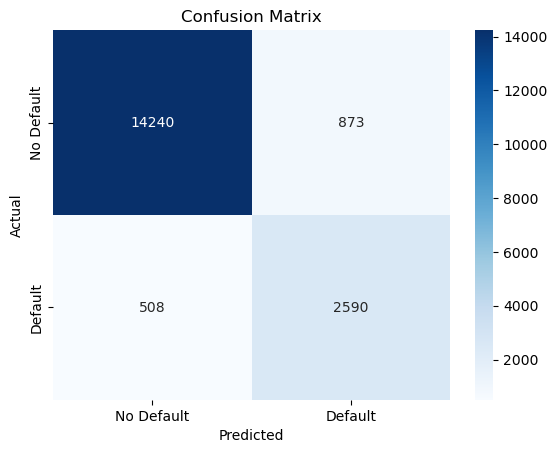

              precision    recall  f1-score   support

           0       0.97      0.94      0.95     15113
           1       0.75      0.84      0.79      3098

    accuracy                           0.92     18211
   macro avg       0.86      0.89      0.87     18211
weighted avg       0.93      0.92      0.93     18211



In [136]:

y_proba = xgb_best.predict_proba(X_test)[:,1]


y_pred = xgb_best.predict(X_test)


roc_auc = roc_auc_score(y_test, y_proba)
print("Test ROC-AUC:", roc_auc)


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,fmt='d',annot=True,cmap='Blues',xticklabels=["No Default","Default"], yticklabels=["No Default","Default"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

print(classification_report(y_test,y_pred))



We can see that, the tuned XGBoost model performs well at identifying risky borrowers. It correctly catches 84% of actual defaults, which is important to minimize financial loss, while also maintaining a reasonable precision of 75% to avoid too many false alarms. Most non-default customers are predicted correctly, giving an overall accuracy of 92% and a ROC-AUC of 0.96. This shows the model balances safety and risk detection effectively, with a stronger focus on catching defaults.

In [137]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost Baseline", "XGBoost Tuned"],
    "ROC AUC": [np.mean(rf_scores), np.mean(xgb_scores), roc_auc]
})

comparison

,Model,ROC AUC
0,Random Forest,0.938261
1,XGBoost Baseline,0.952721
2,XGBoost Tuned,0.958881


In [138]:
joblib.dump(xgb_best, "../best_model.pkl")

['../best_model.pkl']

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.5 Feature Importance</b></div>

C:\Users\rhytn\AppData\Local\Temp\ipykernel_11764\236207994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


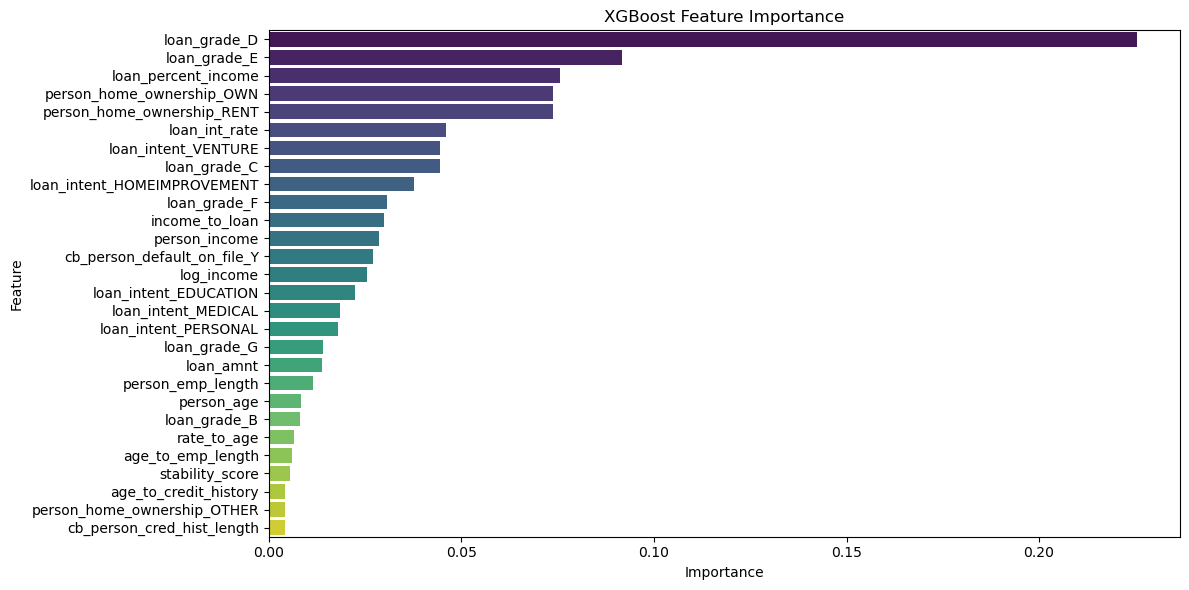

,Feature,Importance
23,loan_grade_D,0.225314
24,loan_grade_E,0.091701
5,loan_percent_income,0.075658
14,person_home_ownership_OWN,0.073895
15,person_home_ownership_RENT,0.073703
4,loan_int_rate,0.046056
20,loan_intent_VENTURE,0.044571
22,loan_grade_C,0.044542
17,loan_intent_HOMEIMPROVEMENT,0.037657
25,loan_grade_F,0.030606


In [139]:


importance = xgb_best.feature_importances_
features = X_train.columns


feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# Display top 10 features
display(feat_imp_df.head(10))